# Read output history and map files from Delft3D - netcdf format

Author: Sofia Midauar

Date: Feb 2024

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import glob2 as glob
import platform
import os
import sys
import seaborn as sns
import re
from matplotlib import dates as mpl_dates
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import calendar
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Functions

In [4]:
# Define the function to assign the corresponding depth to the layer centre from Delft
def assign_depth(layer):
    if layer == 0:
        return 0.92
    elif layer == 1:
        return 2.31
    elif layer == 2:
        return 3.24
    elif layer == 3:
        return 4.16
    elif layer == 4:
        return 5.08
    elif layer == 5:
        return 6.01
    elif layer == 6:
        return 6.93
    elif layer == 7:
        return 7.86
    elif layer == 8:
        return 8.55
    elif layer == 9:
        return 9.01
    elif layer == 10:
        return 9.47
    elif layer == 11:
        return 9.94
    elif layer == 12:
        return 10.40

# Reading all output files - .netcdf

In [5]:
all_files_hist = glob.glob('//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut/*.nc')
all_files_hist

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S52_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S00_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S31_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S11_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-control_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S50_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S22_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S20_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/history_montaut\\trih-S02_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/m

In [6]:
all_files_map = glob.glob('//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut/*.nc')
all_files_map

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S10_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S30_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S20_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S01_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S50_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S11_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S41_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-S31_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/map_montaut\\trim-control_mdf22_sens_test.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files

In [7]:
# Read CONTROL output files - MAP and HIST
map_mdf_control = xr.open_dataset(all_files_map[0], decode_times = True)
hist_mdf_control = xr.open_dataset(all_files_hist[0], decode_times = True)

# Water depth

In [8]:
# Creates dataframe with all data for comparison - DEEP location (NOSTAT = 3)
comp_depth = hist_mdf_control.copy()
comp_depth = comp_depth['ZWL'].sel(NOSTAT = 3).to_dataframe()
comp_depth.rename(columns = {comp_depth.columns[0]:'station_name', comp_depth.columns[1]:'coord_x', 
                           comp_depth.columns[2]:'coord_y', comp_depth.columns[3]:'depth_deep_control'}, inplace = True)
comp_depth.reset_index(inplace = True)
comp_depth['time'] = pd.to_datetime(comp_depth['time']) # transforms datatype to datetime
comp_depth.set_index('time', inplace = True)
comp_depth['depth_deep_control'] = (comp_depth['depth_deep_control'] + 14.29) # 14.29m is the maximum depth at the deep location
comp_depth = comp_depth[['station_name', 'depth_deep_control']]

comp_depth.head(2)

,station_name,depth_deep_control
time,,
2022-09-09 00:00:00,b'deep ',8.650000
2022-09-09 06:00:00,b'deep ',8.648952


In [9]:
# Read files and add columns for each run - DEEP LOCATION (maximum depth = 14.29 m)
for file in range(1,len(all_files_hist),1):
    hist_mdf = xr.open_dataset(all_files_hist[file], decode_times = True)
    temporary = hist_mdf['ZWL'].sel(NOSTAT = 3).to_dataframe()
    temporary.rename(columns = {temporary.columns[0]:'station_name', temporary.columns[1]:'coord_x', 
                                temporary.columns[2]:'coord_y',
                                temporary.columns[3]:('depth_' + os.path.basename(all_files_hist[file])[5:8])}, inplace = True)
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time']) # transforms datatype to datetime
    temporary.set_index('time', inplace = True)
    temporary[('depth_' + os.path.basename(all_files_hist[file])[5:8])] = (temporary[('depth_' + os.path.basename(all_files_hist[file])[5:8])] + 14.29)
    temporary = temporary[temporary.columns[[0,-1]]]
    # Join result to dataframe with control run output for comparison
    comp_depth = comp_depth.merge(temporary, on = ['time', 'station_name'])

comp_depth.drop('station_name', axis = 1, inplace = True)
comp_depth['month'] = comp_depth.index.month
comp_depth['month_str'] = comp_depth['month'].apply(lambda x: calendar.month_abbr[x])
comp_depth.head(2)

,depth_deep_control,depth_S00,depth_S31,depth_S11,depth_con,depth_S50,depth_S22,depth_S20,depth_S02,depth_S41,depth_S40,depth_S42,depth_S32,depth_S51,depth_S10,depth_S01,depth_S30,depth_S12,depth_S21,month,month_str
time,,,,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.65000,8.650000,8.650000,8.650000,8.650000,9,Sep
2022-09-09 06:00:00,8.648952,8.648952,8.648964,8.648932,8.648952,8.648956,8.648955,8.648951,8.648951,8.648952,8.648951,8.648952,8.648967,8.648952,8.64897,8.648952,8.648956,8.648913,8.648952,9,Sep


In [10]:
# Create df with differences between scenarios and the control run
delta_depth = comp_depth.copy()
for scenario in range(1,len(delta_depth.columns)-2,1):
    delta_depth['delta_' + 
                delta_depth.columns[scenario][6:10]] = (delta_depth[delta_depth.columns[0]] - 
                                                        delta_depth[delta_depth.columns[scenario]])

delta_depth = delta_depth[delta_depth.columns[21:]] # subset df for only delta columns
    
delta_depth.head(2)

,delta_S00,delta_S31,delta_S11,delta_con,delta_S50,delta_S22,delta_S20,delta_S02,delta_S41,delta_S40,delta_S42,delta_S32,delta_S51,delta_S10,delta_S01,delta_S30,delta_S12,delta_S21
time,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.0
2022-09-09 06:00:00,9.536743e-07,-0.000011,0.00002,9.536743e-07,-0.000004,-0.000003,0.000002,0.000002,9.536743e-07,0.000002,9.536743e-07,-0.000014,0.0,-0.000017,9.536743e-07,-0.000004,0.000039,0.0


In [11]:
## DATAFRAME FOR CREATING BOXPLOTS WITH MONTHLY PLOTS
# Read files and add rows with identification for each run - DEEP LOCATION (maximum depth = 14.29 m)
# resulting dataframe has two columns - first with data and second with scenario
for file in range(0,len(all_files_hist),1):
    hist_mdf = xr.open_dataset(all_files_hist[file], decode_times = True)
    temporary = hist_mdf['ZWL'].sel(NOSTAT = 3).to_dataframe()
    temporary = pd.DataFrame(temporary[temporary.columns[-1]])
    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[1]:'depth_m'}, inplace = True)
    temporary[temporary.columns[1]] = (temporary[temporary.columns[1]] + 14.29)
    temporary['scenario'] = (os.path.basename(all_files_hist[file])[5:8])
    # Join result to dataframe with control run output for comparison
    if file == 0:
        bp_comp_depth = temporary
    else:
        bp_comp_depth = pd.concat([bp_comp_depth, temporary])

bp_comp_depth['time'] = pd.to_datetime(bp_comp_depth['time'])
bp_comp_depth.set_index('time', inplace = True)
bp_comp_depth['month'] = bp_comp_depth.index.month
bp_comp_depth['month_str'] = bp_comp_depth['month'].apply(lambda x: calendar.month_abbr[x])
bp_comp_depth.reset_index(drop = True, inplace = True)
bp_comp_depth.head(2)

,depth_m,scenario,month,month_str
0,8.650000,S52,9,Sep
1,8.648952,S52,9,Sep


In [12]:
# Create dataframe for deviation comparison (RMSD)
scenarios_RMSD = pd.DataFrame(columns = ['Low', 'Medium', 'High'])
scenarios_RMSD['parameter'] = ['Secchi depth', 'Dalton number', 'Stanton number', 'Vertical diffusivity',
                              'Vertical viscosity', 'Horizontal viscosity and diffusivity']
scenarios_RMSD.set_index('parameter', inplace = True)
scenarios_RMSD

,Low,Medium,High
parameter,,,
Secchi depth,NaN,NaN,NaN
Dalton number,NaN,NaN,NaN
Stanton number,NaN,NaN,NaN
Vertical diffusivity,NaN,NaN,NaN
Vertical viscosity,NaN,NaN,NaN
Horizontal viscosity and diffusivity,NaN,NaN,NaN


In [13]:
## Prepara data for table of deviations from all scenarios
# Root mean square deviation
dev_df = comp_depth.copy()
# Number of rows (n)
n = len(dev_df)

MAD_li = []
RMSD_li = []

for scen in range(1,len(dev_df.columns)-2,1):
    # calculates absolute deviation and squared deviation from control run for all scenarios
    dev_df['abs_dev_' + 
           (os.path.basename(dev_df.columns[scen])[6:9])] = abs(dev_df['depth_' + 
                                                                       (os.path.basename(dev_df.columns[scen])[6:9])] -
                                                                dev_df['depth_deep_control'])
    dev_df['sq_dev_' + 
           (os.path.basename(dev_df.columns[scen])[6:9])] = (dev_df['depth_' + 
                                                                    (os.path.basename(dev_df.columns[scen])[6:9])] - 
                                                             dev_df['depth_deep_control']) ** 2
    dev_df['bias' + 
           (os.path.basename(dev_df.columns[scen])[6:9])] = (dev_df['depth_deep_control'] - 
                                                             dev_df['depth_' + (os.path.basename(dev_df.columns[scen])[6:9])])
    # calculates the mean absolute deviation and the root mean squared deviation
    MAD = (1/n) * dev_df['abs_dev_' + (os.path.basename(dev_df.columns[scen])[6:9])].sum()
    MAD_li.append(MAD)
    RMSD = ((1/n) * (dev_df['sq_dev_' + (os.path.basename(dev_df.columns[scen])[6:9])].sum()) ) ** 0.5
    RMSD_li.append(RMSD)

dev_df.head(3)

,depth_deep_control,depth_S00,depth_S31,depth_S11,depth_con,depth_S50,depth_S22,depth_S20,depth_S02,depth_S41,depth_S40,depth_S42,depth_S32,depth_S51,depth_S10,depth_S01,depth_S30,depth_S12,depth_S21,month,month_str,abs_dev_S00,sq_dev_S00,biasS00,abs_dev_S31,sq_dev_S31,biasS31,abs_dev_S11,sq_dev_S11,biasS11,abs_dev_con,sq_dev_con,biascon,abs_dev_S50,sq_dev_S50,biasS50,abs_dev_S22,sq_dev_S22,biasS22,abs_dev_S20,sq_dev_S20,biasS20,abs_dev_S02,sq_dev_S02,biasS02,abs_dev_S41,sq_dev_S41,biasS41,abs_dev_S40,sq_dev_S40,biasS40,abs_dev_S42,sq_dev_S42,biasS42,abs_dev_S32,sq_dev_S32,biasS32,abs_dev_S51,sq_dev_S51,biasS51,abs_dev_S10,sq_dev_S10,biasS10,abs_dev_S01,sq_dev_S01,biasS01,abs_dev_S30,sq_dev_S30,biasS30,abs_dev_S12,sq_dev_S12,biasS12,abs_dev_S21,sq_dev_S21,biasS21
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,8.650000,9,Sep,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
2022-09-09 06:00:00,8.648952,8.648952,8.648964,8.648932,8.648952,8.648956,8.648955,8.648951,8.648951,8.648952,8.648951,8.648952,8.648967,8.648952,8.648970,8.648952,8.648956,8.648913,8.648952,9,Sep,9.536743e-07,9.094947e-13,9.536743e-07,0.000011,1.309672e-10,-0.000011,0.000020,4.010872e-10,0.000020,9.536743e-07,9.094947e-13,9.536743e-07,0.000004,1.455192e-11,-0.000004,0.000003,8.185452e-12,-0.000003,0.000002,3.637979e-12,0.000002,0.000002,3.637979e-12,0.000002,9.536743e-07,9.094947e-13,9.536743e-07,0.000002,3.637979e-12,0.000002,9.536743e-07,9.094947e-13,9.536743e-07,0.000014,2.046363e-10,-0.000014,0.000000e+00,0.000000e+00,0.000000e+00,0.000017,2.946763e-10,-0.000017,9.536743e-07,9.094947e-13,9.536743e-07,0.000004,1.455192e-11,-0.000004,0.000039,1.528861e-09,0.000039,0.000000,0.000000e+00,0.000000
2022-09-09 12:00:00,8.647652,8.647652,8.647684,8.647583,8.647655,8.647649,8.647673,8.647652,8.647659,8.647655,8.647655,8.647655,8.647687,8.647651,8.647726,8.647657,8.647673,8.647512,8.647657,9,Sep,0.000000e+00,0.000000e+00,0.000000e+00,0.000032,1.051376e-09,-0.000032,0.000069,4.714821e-09,0.000069,3.814697e-06,1.455192e-11,-3.814697e-06,0.000003,8.185452e-12,0.000003,0.000021,4.401954e-10,-0.000021,0.000000,0.000000e+00,0.000000,0.000008,5.820766e-11,-0.000008,3.814697e-06,1.455192e-11,-3.814697e-06,0.000003,8.185452e-12,-0.000003,3.814697e-06,1.455192e-11,-3.814697e-06,0.000035,1.245098e-09,-0.000035,9.536743e-07,9.094947e-13,9.536743e-07,0.000074,5.533366e-09,-0.000074,5.722046e-06,3.274181e-11,-5.722046e-06,0.000021,4.401954e-10,-0.000021,0.000139,1.938679e-08,0.000139,0.000006,3.274181e-11,-0.000006


In [14]:
# creates list with all scenarios
scenarios_li = []
for scenario in range(1, len(comp_depth.columns)-2, 1):
    scenarios_li.append(comp_depth.columns[scenario])

# adds resulting calculation to dataframe
scenarios_dev = pd.DataFrame(scenarios_li, columns = ['scenarios'])
scenarios_dev['MAD'] = MAD_li
scenarios_dev['RMSD'] = RMSD_li
scenarios_dev.head(3)

,scenarios,MAD,RMSD
0,depth_S00,0.000773,0.000839
1,depth_S31,0.000402,0.000453
2,depth_S11,0.003650,0.003849


In [114]:
# export df to excel for formatting
scenarios_dev.to_csv('scenarios_dev.csv')

In [15]:
# Creates list with all estimated bias from scenarios (divides the sum of bias by the number of entries)
bias_li = []

for scen in range(1,len(comp_depth.columns)-2, 1):
    bias = ((dev_df['bias' + 
                   (os.path.basename(comp_depth.columns[scen])[6:9])].sum()) / 
            (len(dev_df)))
    bias_li.append(bias)

bias_li

[np.float32(0.0007728424),
 np.float32(-0.00037669137),
 np.float32(0.0036498564),
 np.float32(0.00019188826),
 np.float32(2.4644076e-05),
 np.float32(-0.027396992),
 np.float32(0.006827454),
 np.float32(-0.00052566093),
 np.float32(0.00022326298),
 np.float32(0.00018055734),
 np.float32(0.00020689073),
 np.float32(-0.00042605607),
 np.float32(-3.5550581e-06),
 np.float32(-0.0034809778),
 np.float32(-0.00019584276),
 np.float32(-0.00013493243),
 np.float32(0.0070333215),
 np.float32(-0.0047371835)]

In [16]:
# Creates df for calculating bias per scenario
bias_df = pd.DataFrame(comp_depth.columns[1:-2])
bias_df.rename(columns = {bias_df.columns[0]:'scenario'}, inplace = True)
bias_df['bias'] = bias_li

bias_df.head(3)

,scenario,bias
0,depth_S00,0.000773
1,depth_S31,-0.000377
2,depth_S11,0.003650


In [115]:
bias_df.to_csv('bias_df.csv')

# Figures - Water level

In [20]:
comp_depth.columns

Index(['depth_deep_control', 'depth_S00', 'depth_S01', 'depth_S02',
       'depth_S10', 'depth_S11', 'depth_S12', 'depth_S20', 'depth_S21',
       'depth_S22', 'depth_S30', 'depth_S31', 'depth_S32', 'depth_S40',
       'depth_S41', 'depth_S42', 'depth_S50', 'depth_S51', 'depth_S52',
       'month', 'month_str'],
      dtype='object')

<ipython-input-78-774474aba773>:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1,0].set_xticklabels(xlabels_new)


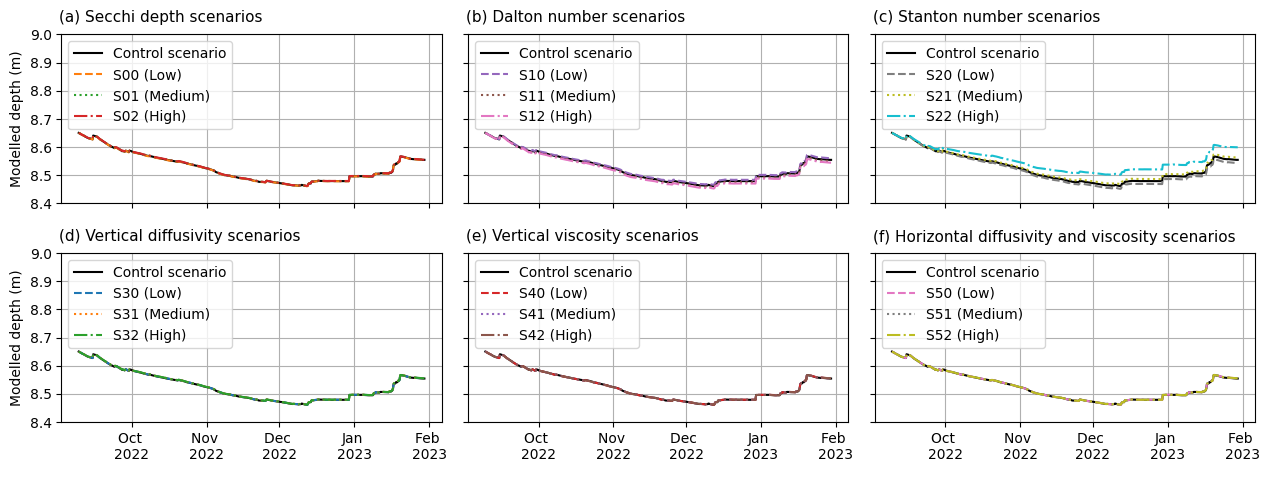

In [78]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [13,5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        ax[0,nplot].plot(comp_depth.index, comp_depth['depth_deep_control'], color='k', 
                           linestyle='-', label = 'Control scenario')        
        ax[0,nplot].plot(comp_depth.index, comp_depth[comp_depth.columns[1+3*nplot]], color=pal.as_hex()[1+3*nplot], 
                           linestyle='--', label = os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + ' (Low)')
        ax[0,nplot].plot(comp_depth.index, comp_depth[comp_depth.columns[2+3*nplot]], color=pal.as_hex()[2+3*nplot], 
                           linestyle=':', label = os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + ' (Medium)')
        ax[0,nplot].plot(comp_depth.index, comp_depth[comp_depth.columns[3+3*nplot]], color=pal.as_hex()[3+3*nplot], 
                           linestyle='-.', label = os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + ' (High)')
        ax[0,nplot].set_xlim(ax[0,nplot].get_xlim()[0], ax[0,nplot].get_xlim()[-1])
        ax[0,nplot].set_ylim(8.4,9)
        ax[0,nplot].legend(loc = 'upper left')
        ax[0,nplot].grid(True)

    # second row of plots
    if (3 <= nplot & nplot < 6):
        ax[1,nplot-3].plot(comp_depth.index, comp_depth['depth_deep_control'], color='k', 
                           linestyle='-', label = 'Control scenario')        
        ax[1,nplot-3].plot(comp_depth.index, comp_depth[comp_depth.columns[1+3*nplot]], color=pal.as_hex()[1+3*nplot], 
                           linestyle='--', label = os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + ' (Low)')
        ax[1,nplot-3].plot(comp_depth.index, comp_depth[comp_depth.columns[2+3*nplot]], color=pal.as_hex()[2+3*nplot], 
                           linestyle=':', label = os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + ' (Medium)')
        ax[1,nplot-3].plot(comp_depth.index, comp_depth[comp_depth.columns[3+3*nplot]], color=pal.as_hex()[3+3*nplot], 
                           linestyle='-.', label = os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + ' (High)')
        ax[1,nplot-3].legend(loc = 'upper left')
        ax[1,nplot-3].grid(True)

# Add formatted date labels
xlabels = ['Oct 2022', 'Nov 2022', 'Dec 2022', 'Jan 2023', 'Feb 2023']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[1,0].set_xticklabels(xlabels_new)

ax[0,0].yaxis.set_label_text(u'Modelled depth (m)')
ax[1,0].yaxis.set_label_text(u'Modelled depth (m)')

ax[0,0].text(19236, 9.045, '(a) Secchi depth scenarios', color = 'k', fontsize = 11)
ax[0,1].text(19236, 9.045, '(b) Dalton number scenarios', color = 'k', fontsize = 11)
ax[0,2].text(19236, 9.045, '(c) Stanton number scenarios', color = 'k', fontsize = 11)

ax[1,0].text(19236, 9.045, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 11)
ax[1,1].text(19236, 9.045, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 11)
ax[1,2].text(19236, 9.040, '(f) Horizontal diffusivity and viscosity scenarios', color = 'k', fontsize = 11)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('timeseries_scenarios_depth_montaut.jpeg', dpi=600, bbox_inches='tight')

plt.show();

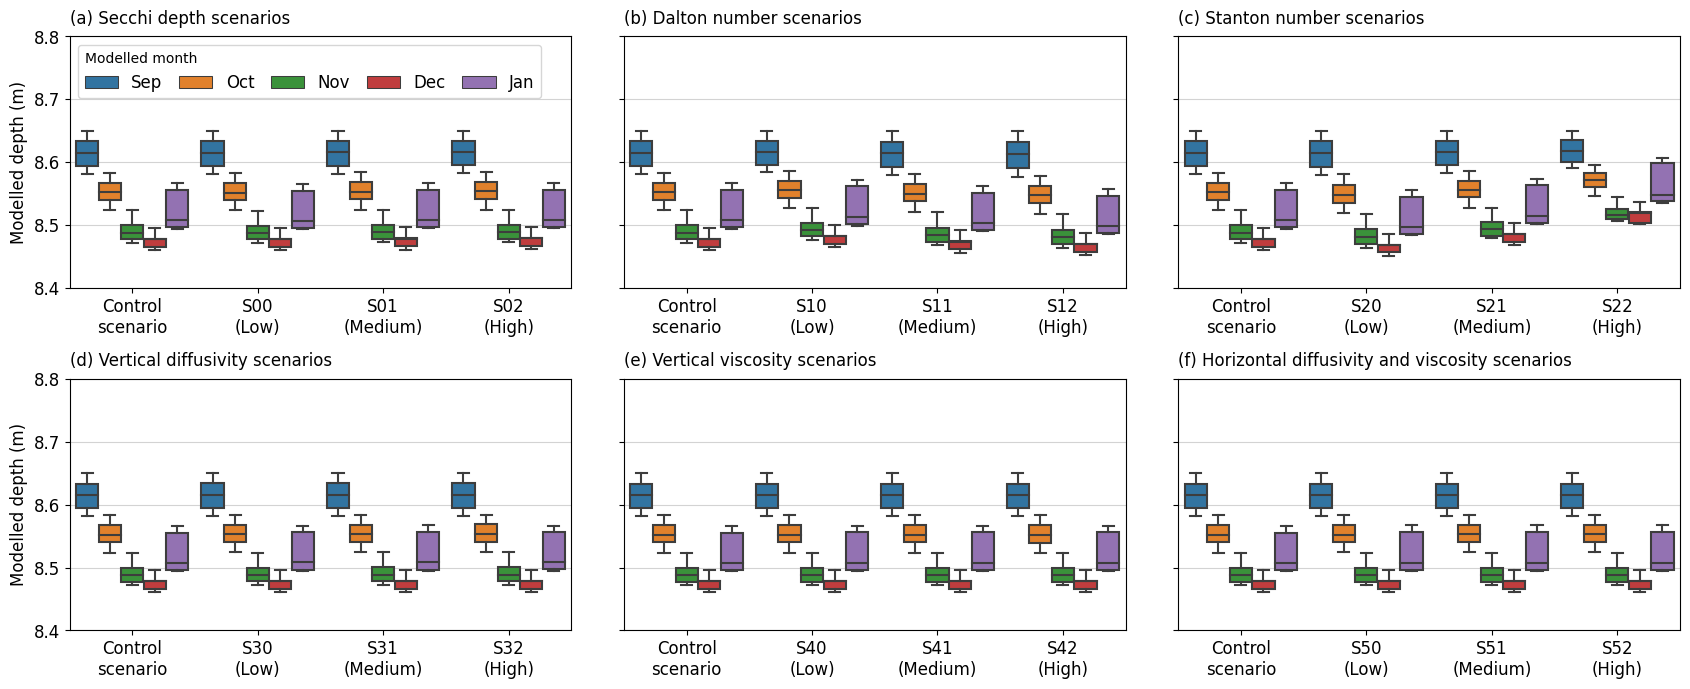

In [81]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [17,7], sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        sns.boxplot(x = "scenario", y = "depth_m", 
                    data = bp_comp_depth.loc[bp_comp_depth['scenario'].isin(['con',
                                                                             comp_depth.columns[1+3*nplot][6:9],
                                                                             comp_depth.columns[2+3*nplot][6:9],
                                                                             comp_depth.columns[3+3*nplot][6:9]])],
                    width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:5], ax = ax[0,nplot], hue = 'month_str')
        ax[0,nplot].set_xticks([0,1,2,3], ['Control\nscenario',
                                           os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + '\n(Low)',
                                           os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + '\n(Medium)',
                                           os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + '\n(High)'],
                              fontsize = 12) 
        ax[0,nplot].xaxis.set_label_text("")
        ax[0,nplot].yaxis.set_label_text('')
        ax[0,nplot].set_ylim(8.4,8.8)
        ax[0,nplot].set_axisbelow(True)
        ax[0,nplot].grid(color='lightgray', axis = 'y')
        ax[0,nplot].legend_.remove()
        ax[0,nplot].tick_params(axis = 'y', which = 'major', labelsize = 12)

    # second row of plots
    if (3 <= nplot & nplot < 6):
        sns.boxplot(x = "scenario", y = "depth_m", 
                    data = bp_comp_depth.loc[bp_comp_depth['scenario'].isin(['con',
                                                                             comp_depth.columns[1+3*nplot][6:9],
                                                                             comp_depth.columns[2+3*nplot][6:9],
                                                                             comp_depth.columns[3+3*nplot][6:9]])],
                    width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:5], ax = ax[1,nplot-3], hue = 'month_str')
        ax[1,nplot-3].set_xticks([0,1,2,3], ['Control\nscenario',
                                             os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + '\n(Low)',
                                             os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + '\n(Medium)',
                                             os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + '\n(High)'],
                                fontsize = 12)      
        ax[1,nplot-3].xaxis.set_label_text("")
        ax[1,nplot-3].yaxis.set_label_text('')
        ax[1,nplot-3].set_axisbelow(True)
        ax[1,nplot-3].grid(color='lightgray', axis = 'y')
        ax[1,nplot-3].legend_.remove()
        ax[1,nplot-3].tick_params(axis = 'y', which = 'major', labelsize = 12)

# ax[0,0].vlines(x = 0.5, ymin = 8.5, ymax = 8.9,  color='k', linestyle='--')
# ax[1,0].vlines(x = 0.5, ymin = 8.5, ymax = 8.9,  color='k', linestyle='--')
        
ax[0,0].yaxis.set_label_text(u'Modelled depth (m)', fontsize = 12)
ax[1,0].yaxis.set_label_text(u'Modelled depth (m)', fontsize = 12)

ax[0,0].text(-0.5, 8.82, '(a) Secchi depth scenarios', color = 'k', fontsize = 12)
ax[0,1].text(-0.5, 8.82, '(b) Dalton number scenarios', color = 'k', fontsize = 12)
ax[0,2].text(-0.5, 8.82, '(c) Stanton number scenarios', color = 'k', fontsize = 12)

ax[1,0].text(-0.5, 8.82, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 12)
ax[1,1].text(-0.5, 8.82, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 12)
ax[1,2].text(-0.5, 8.82, '(f) Horizontal diffusivity and viscosity scenarios', color = 'k', fontsize = 12)

# ax[0,0].legend(bbox_to_anchor=(0.96,0.295), loc="lower right",  bbox_transform=fig.transFigure)

ax[0,0].legend(title = "Modelled month", loc="upper left", ncol = 5, fontsize = 12,
               frameon = True, columnspacing = 1)._legend_box.align = "left"

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('monthly_boxplots_scenarios_depth_montaut.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

In [33]:
sns.color_palette("hls", 24)

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.5012, 0.33999999999999997),
 (0.86, 0.6312, 0.33999999999999997),
 (0.86, 0.7612000000000001, 0.33999999999999997),
 (0.8287999999999999, 0.86, 0.33999999999999997),
 (0.6988, 0.86, 0.33999999999999997),
 (0.5688000000000001, 0.86, 0.33999999999999997),
 (0.43879999999999986, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.3712),
 (0.33999999999999997, 0.86, 0.5012000000000001),
 (0.33999999999999997, 0.86, 0.6312),
 (0.33999999999999997, 0.86, 0.7612000000000001),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.6988, 0.86),
 (0.33999999999999997, 0.5688000000000001, 0.86),
 (0.33999999999999997, 0.43879999999999986, 0.86),
 (0.3712, 0.33999999999999997, 0.86),
 (0.5011999999999995, 0.33999999999999997, 0.86),
 (0.6311999999999998, 0.33999999999999997, 0.86),
 (0.7612000000000001, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.8287999999999999),
 (0.86, 0.33999999999999997, 0.6987999999999996),
 (0.86, 0.33999999999999997, 0.5688000000000001),
 (0.86, 0.33999999999999997, 0.43879999999999986)]

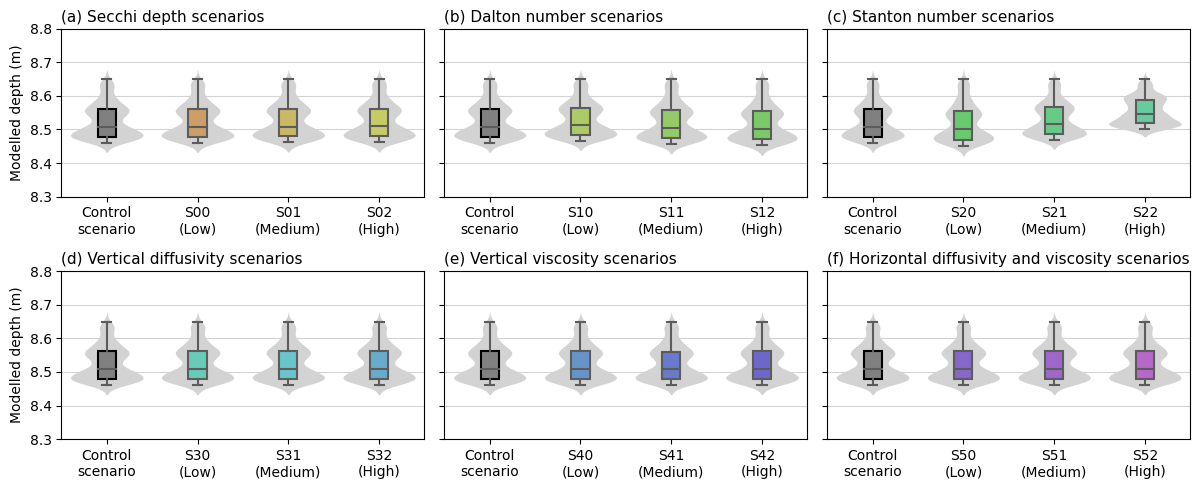

In [85]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [12.5,5], sharey = True)
pal = sns.color_palette("hls", 24)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        sns.boxplot(x = "variable", y = "value", 
            data = pd.melt(comp_depth[['depth_deep_control', 
                                       comp_depth.columns[1+3*nplot],
                                       comp_depth.columns[2+3*nplot], 
                                       comp_depth.columns[3+3*nplot]]]),
                    width = 0.2, boxprops = {'zorder': 2}, palette = pal[(1+3*nplot):(3+3*nplot)+2], ax = ax[0,nplot])
        sns.violinplot(data = comp_depth[['depth_deep_control', 
                                          comp_depth.columns[1+3*nplot],
                                          comp_depth.columns[2+3*nplot], 
                                          comp_depth.columns[3+3*nplot]]],
                       inner = None, linewidth = 0, width = 0.8, color = 'lightgray', ax = ax[0,nplot])    
        ax[0,nplot].xaxis.set_label_text("")
        ax[0,nplot].yaxis.set_label_text('')
        ax[0,nplot].set_xticks([0,1,2,3], ['Control\nscenario',
                                           os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + '\n(Low)',
                                           os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + '\n(Medium)',
                                           os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + '\n(High)'])
        ax[0,nplot].set_axisbelow(True)
        ax[0,nplot].grid(color='lightgray', axis = 'y')

    # second row of plots
    if (3 <= nplot & nplot < 6):
        sns.boxplot(x = "variable", y = "value", 
            data = pd.melt(comp_depth[['depth_deep_control', 
                                       comp_depth.columns[1+3*nplot],
                                       comp_depth.columns[2+3*nplot], 
                                       comp_depth.columns[3+3*nplot]]]),
                    width = 0.2, boxprops = {'zorder': 2}, palette = pal[(1+3*nplot):(3+3*nplot)+2], ax = ax[1,nplot-3])
        sns.violinplot(data = comp_depth[['depth_deep_control', 
                                          comp_depth.columns[1+3*nplot],
                                          comp_depth.columns[2+3*nplot], 
                                          comp_depth.columns[3+3*nplot]]],
                       inner = None, linewidth = 0, width = 0.8, color = 'lightgray', ax = ax[1,nplot-3])    
        ax[1,nplot-3].xaxis.set_label_text("")
        ax[1,nplot-3].yaxis.set_label_text('')
        ax[1,nplot-3].set_xticks([0,1,2,3], ['Control\nscenario',
                                           os.path.basename(comp_depth.columns[1+3*nplot])[6:9] + '\n(Low)',
                                           os.path.basename(comp_depth.columns[2+3*nplot])[6:9] + '\n(Medium)',
                                           os.path.basename(comp_depth.columns[3+3*nplot])[6:9] + '\n(High)'])
        ax[1,nplot-3].set_axisbelow(True)
        ax[1,nplot-3].grid(color='lightgray', axis = 'y')

# set same colour always for the control run
for i in range(0,6,1):
    if (0 <= i & i < 3):
        control_plot = ax[0,i].patches[0]
        control_plot.set_facecolor('gray')
        control_plot.set_edgecolor('black')
    if (3 <= i & i < 6):
        control_plot = ax[1,i-3].patches[0]
        control_plot.set_facecolor('gray')
        control_plot.set_edgecolor('black')
        
ax[0,0].set_ylim(8.3,8.8)
        
ax[0,0].yaxis.set_label_text(u'Modelled depth (m)')
ax[1,0].yaxis.set_label_text(u'Modelled depth (m)')

ax[0,0].text(-0.5, 8.82, '(a) Secchi depth scenarios', color = 'k', fontsize = 11)
ax[0,1].text(-0.5, 8.82, '(b) Dalton number scenarios', color = 'k', fontsize = 11)
ax[0,2].text(-0.5, 8.82, '(c) Stanton number scenarios', color = 'k', fontsize = 11)

ax[1,0].text(-0.5, 8.82, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 11)
ax[1,1].text(-0.5, 8.82, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 11)
ax[1,2].text(-0.5, 8.82, '(f) Horizontal diffusivity and viscosity scenarios', color = 'k', fontsize = 11)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('boxplots_scenarios_depth_montaut.jpeg', dpi=600, bbox_inches='tight')

plt.show();

In [33]:
delta_depth.columns

Index(['delta_S00', 'delta_S01', 'delta_S02', 'delta_S10', 'delta_S11',
       'delta_S12', 'delta_S20', 'delta_S21', 'delta_S22', 'delta_S30',
       'delta_S31', 'delta_S32', 'delta_S40', 'delta_S41', 'delta_S42',
       'delta_S50', 'delta_S51', 'delta_S52'],
      dtype='object')

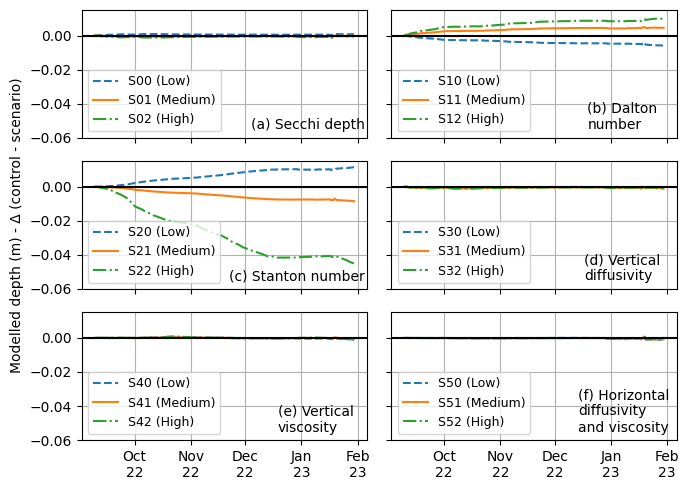

In [79]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = [7,5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 2):
        ax[0,nplot].plot(delta_depth.index, 
                         delta_depth[delta_depth.columns[0+3*nplot]], 
                         color=pal.as_hex()[0], 
                         linestyle='--', label = os.path.basename(delta_depth.columns[0+3*nplot])[6:9] + ' (Low)')
        ax[0,nplot].plot(delta_depth.index, 
                         delta_depth[delta_depth.columns[1+3*nplot]], 
                         color=pal.as_hex()[1], 
                         linestyle='-', label = os.path.basename(delta_depth.columns[1+3*nplot])[6:9] + ' (Medium)')
        ax[0,nplot].plot(delta_depth.index, 
                         delta_depth[delta_depth.columns[2+3*nplot]], 
                         color=pal.as_hex()[2], 
                         linestyle='-.', label = os.path.basename(delta_depth.columns[2+3*nplot])[6:9] + ' (High)')
        ax[0,nplot].set_xlim(ax[0,nplot].get_xlim()[0], ax[0,nplot].get_xlim()[-1])
        ax[0,nplot].hlines(y=0, xmin=ax[0,nplot].get_xlim()[0], xmax=ax[0,nplot].get_xlim()[-1], color='k')
        ax[0,nplot].legend(loc = 'lower left', fontsize = 9)
        ax[0,nplot].grid(True)
        
    if (2 <= nplot & nplot < 4):
        ax[1,nplot-2].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[0+3*nplot]], 
                           color=pal.as_hex()[0], 
                           linestyle='--', label = os.path.basename(delta_depth.columns[0+3*nplot])[6:9] + ' (Low)')
        ax[1,nplot-2].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[1+3*nplot]], 
                           color=pal.as_hex()[1], 
                           linestyle='-', label = os.path.basename(delta_depth.columns[1+3*nplot])[6:9] + ' (Medium)')
        ax[1,nplot-2].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[2+3*nplot]], 
                           color=pal.as_hex()[2], 
                           linestyle='-.', label = os.path.basename(delta_depth.columns[2+3*nplot])[6:9] + ' (High)')
        ax[1,nplot-2].set_xlim(ax[1,nplot-2].get_xlim()[0], ax[1,nplot-2].get_xlim()[-1])
        ax[1,nplot-2].set_ylim(-0.06,0.015)
        ax[1,nplot-2].hlines(y=0, xmin=ax[0,nplot-2].get_xlim()[0], xmax=ax[1,nplot-2].get_xlim()[-1], color='k')
        ax[1,nplot-2].legend(loc = 'lower left', fontsize = 9)
        ax[1,nplot-2].grid(True)

    # second row of plots
    if (4 <= nplot & nplot < 6):
        ax[2,nplot-4].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[0+3*nplot]], 
                           color=pal.as_hex()[0], 
                           linestyle='--', label = os.path.basename(delta_depth.columns[0+3*nplot])[6:9] + ' (Low)')
        ax[2,nplot-4].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[1+3*nplot]], 
                           color=pal.as_hex()[1], 
                           linestyle='-', label = os.path.basename(delta_depth.columns[1+3*nplot])[6:9] + ' (Medium)')
        ax[2,nplot-4].plot(delta_depth.index, 
                           delta_depth[delta_depth.columns[2+3*nplot]], 
                           color=pal.as_hex()[2], 
                           linestyle='-.', label = os.path.basename(delta_depth.columns[2+3*nplot])[6:9] + ' (High)')
        ax[2,nplot-4].hlines(y=0, xmin=ax[1,nplot-4].get_xlim()[0], xmax=ax[1,nplot-4].get_xlim()[-1], color='k')
        ax[2,nplot-4].legend(loc = 'lower left', fontsize = 9)
        ax[2,nplot-4].grid(True)
#         ax[1,nplot-3].set_xticks([0,1,2,3,4,5], 
#                                  ['Sep\n2022', 'Oct\n2022', 'Nov\n2022', 'Dec\n2022', 'Jan\n2023', 'Feb\n2023'])

# Format date labels
myFmt = mdates.DateFormatter('%b\n%y') # date format with month in string!
ax[0,0].xaxis.set_major_formatter(myFmt)

ax[1,0].yaxis.set_label_text(u'Modelled depth (m) - Δ (control - scenario)')

ax[0,0].text(19330, -0.055, '(a) Secchi depth', color = 'k', fontsize = 10)
ax[0,1].text(19345, -0.055, '(b) Dalton\nnumber', color = 'k', fontsize = 10)

ax[1,0].text(19318, -0.055, '(c) Stanton number', color = 'k', fontsize = 10)
ax[1,1].text(19343, -0.055, '(d) Vertical\ndiffusivity', color = 'k', fontsize = 10)

ax[2,0].text(19345, -0.055, '(e) Vertical\nviscosity', color = 'k', fontsize = 10)
ax[2,1].text(19340, -0.055, '(f) Horizontal\ndiffusivity\nand viscosity', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('delta_scenarios_depth_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

# Water temperature

Water temperature plots

In [17]:
# Read files and add columns for each run - DEEP LOCATION (maximum depth = 14.29 m)
for file in range(0,len(all_files_map),1):
    map_mdf = xr.open_dataset(all_files_map[file], decode_times = True)
    temporary = map_mdf['R1'].sel(M = 15, N = 40).to_dataframe()
    temporary.rename(columns = {temporary.columns[2]:('WT_deep_' + 
                                                      os.path.basename(all_files_map[file])[5:8])}, inplace = True)
    temporary.reset_index(inplace = True)
    temporary.drop('LSTSCI', axis = 1, inplace = True)
    temporary.rename(columns = {temporary.columns[1]:'layer_centre'}, inplace = True)
    temporary.set_index('time', inplace = True)
    temporary.drop(temporary.columns[[1,2]], axis = 1, inplace = True)
    temporary = temporary[temporary['WT_deep_' + 
                                    os.path.basename(all_files_map[file])[5:8]] != -999]
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time'], format = "%Y-%m-%d %H:%M:%S")
    # Join result to dataframe with control run output for comparison
    if file == 0:
        comp_wt = temporary.copy()
    else:
        comp_wt = comp_wt.merge(temporary, on = ['time', 'layer_centre'])

# Creates depth column - corresponds to output layer (using function assign_depth created)
comp_wt['depth_m'] = comp_wt['layer_centre'].apply(assign_depth)
comp_wt['depth_m'] = comp_wt['depth_m'].apply(lambda x: round(x, 1)) # rounds decimal places to 1

comp_wt.head(2)

,time,layer_centre,WT_deep_S10,WT_deep_S30,WT_deep_S20,WT_deep_S01,WT_deep_S50,WT_deep_S11,WT_deep_S41,WT_deep_S31,WT_deep_con,WT_deep_S02,WT_deep_S00,WT_deep_S21,WT_deep_S32,WT_deep_S22,WT_deep_S51,WT_deep_S52,WT_deep_S40,WT_deep_S42,WT_deep_S12,depth_m
0,2022-09-09,0,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,24.32,0.9
1,2022-09-09,1,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,25.07,2.3


In [18]:
# Create df with differences between scenarios and the control run
delta_wt = comp_wt.copy()

for scenario in range(3,len(delta_wt.columns)-1,1):
    delta_wt['WT_delta_' + delta_wt.columns[scenario][8:11]] = (delta_wt[delta_wt.columns[2]] - 
                                                                delta_wt[delta_wt.columns[scenario]])
delta_wt.set_index('time', inplace = True)
delta_wt = delta_wt[delta_wt.columns[20:]] # subset df for only delta columns

delta_wt.head(2)

,depth_m,WT_delta_S30,WT_delta_S20,WT_delta_S01,WT_delta_S50,WT_delta_S11,WT_delta_S41,WT_delta_S31,WT_delta_con,WT_delta_S02,WT_delta_S00,WT_delta_S21,WT_delta_S32,WT_delta_S22,WT_delta_S51,WT_delta_S52,WT_delta_S40,WT_delta_S42,WT_delta_S12
time,,,,,,,,,,,,,,,,,,,
2022-09-09,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-09-09,2.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# Creates df for heatmap
heatmap_WT_df = delta_wt.reset_index()
heatmap_WT_df.head(2)

,time,depth_m,WT_delta_S30,WT_delta_S20,WT_delta_S01,WT_delta_S50,WT_delta_S11,WT_delta_S41,WT_delta_S31,WT_delta_con,WT_delta_S02,WT_delta_S00,WT_delta_S21,WT_delta_S32,WT_delta_S22,WT_delta_S51,WT_delta_S52,WT_delta_S40,WT_delta_S42,WT_delta_S12
0,2022-09-09,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-09-09,2.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Creates pivot table with data for heatmap
heatmap_WT_pivot = pd.pivot_table(heatmap_WT_df, index = 'depth_m', columns = 'time',
                                  values = 'WT_delta_S00')

# Creates one dataframe per depth
List = heatmap_WT_df.columns[2:].to_list()
Dictionary = {}

for scenario in List:
    Dictionary[scenario] = pd.pivot_table(heatmap_WT_df, index = 'depth_m', columns = 'time',
                                          values = scenario)
    # Adjusts date format to improve heatmap plot
    Dictionary[scenario] = Dictionary[scenario].unstack()
    Dictionary[scenario] = Dictionary[scenario].reset_index("time")
    Dictionary[scenario] = Dictionary[scenario].pivot(columns = "time")
    Dictionary[scenario] = Dictionary[scenario].sort_values(by = "depth_m")
    Dictionary[scenario] = Dictionary[scenario].droplevel(level = 0, axis = 1)
    Dictionary[scenario].columns = [x.strftime("%b %Y") for x in Dictionary[scenario].columns]

Dictionary[List[0]]

,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Sep 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Oct 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Nov 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec 2022,Dec

# Figures - WT deviation

C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\971828962.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_secchi_depth_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\971828962.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_secchi_depth_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


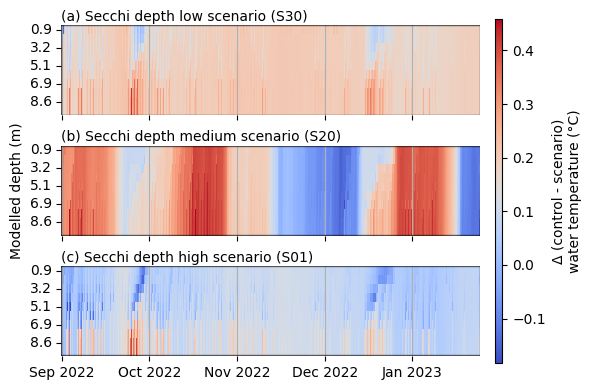

In [25]:
# Plot heatmap for temperature data
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario]].dropna().values.min(),
                    vmax = Dictionary[List[scenario]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Secchi depth ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nwater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
# plt.savefig('heatmap_WT_secchi_depth_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\1077689442.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_dalton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\1077689442.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_dalton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


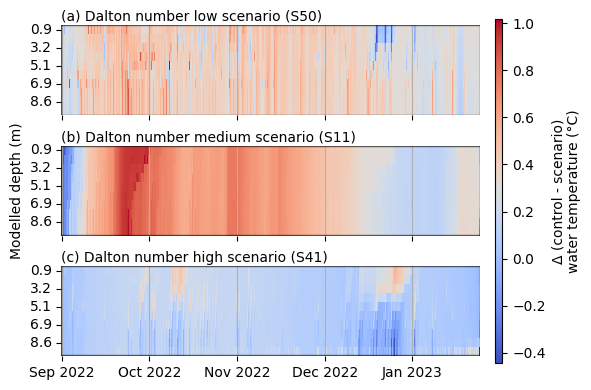

In [27]:
# Plot heatmap for temperature data
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario+3]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario+3]].dropna().values.min(),
                    vmax = Dictionary[List[scenario+3]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Dalton number ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario+3][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nwater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
# plt.savefig('heatmap_WT_dalton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

<ipython-input-124-82f8f20c3496>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_stanton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')
<ipython-input-124-82f8f20c3496>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_stanton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


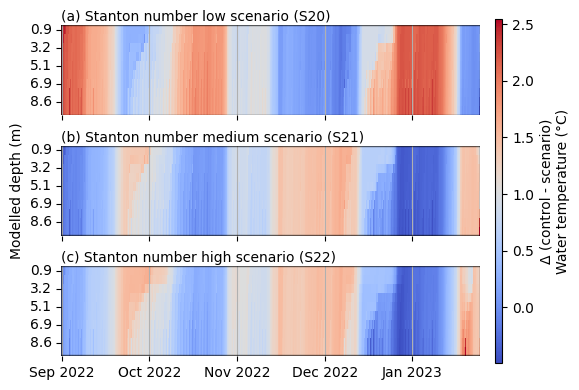

In [124]:
# Plot heatmap for temperature data - scenario S00
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario+6]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario+6]].dropna().values.min(),
                    vmax = Dictionary[List[scenario+6]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Stanton number ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario+6][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nWater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
# plt.savefig('heatmap_WT_stanton_number_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\3340915290.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_vert_diff_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\3340915290.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_vert_diff_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


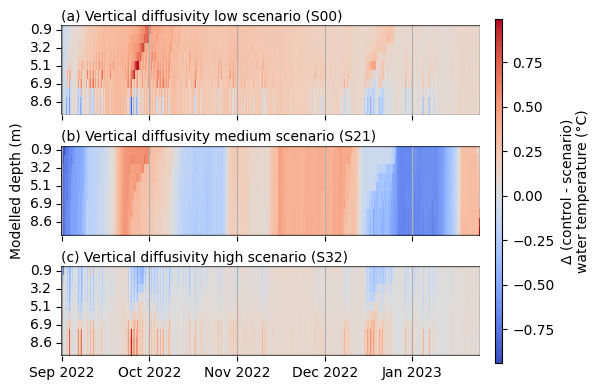

In [29]:
# Plot heatmap for temperature data - scenario S00
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario+9]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario+9]].dropna().values.min(),
                    vmax = Dictionary[List[scenario+9]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Vertical diffusivity ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario+9][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nwater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
plt.savefig('heatmap_WT_vert_diff_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

<ipython-input-126-2bfcdf13af68>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_vert_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')
<ipython-input-126-2bfcdf13af68>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_vert_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


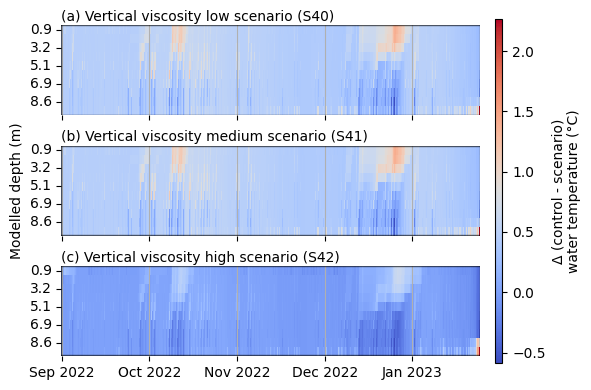

In [126]:
# Plot heatmap for temperature data - scenario S00
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario+12]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario+12]].dropna().values.min(),
                    vmax = Dictionary[List[scenario+12]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Vertical viscosity ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario+12][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nwater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
# plt.savefig('heatmap_WT_vert_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\3712218684.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_hor_diff_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Local\Temp\ipykernel_23884\3712218684.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('heatmap_WT_hor_diff_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')
C:\Users\midauarg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


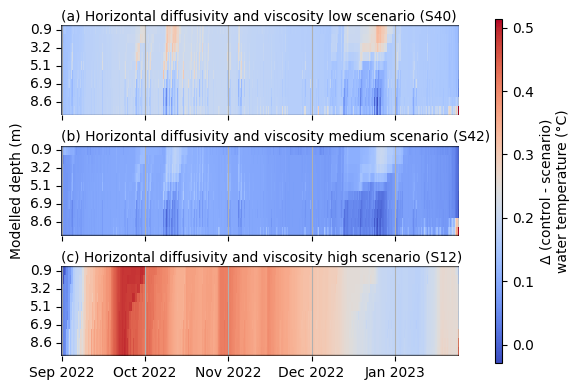

In [31]:
# Plot heatmap for temperature data - scenario S00
fig, ax = plt.subplots(3, 1, figsize = (5,4), sharex = True, tight_layout = True)
plots = ['a', 'b', 'c']
scenarios = ['low', 'medium', 'high']

for scenario in range(0, 3, 1):
    g = sns.heatmap(Dictionary[List[scenario+15]], square = False, linewidth = None, linecolor = None, ax = ax[scenario],
                    xticklabels = 120, yticklabels = 2, cmap = 'coolwarm', cbar = False, 
                    vmin = Dictionary[List[scenario+15]].dropna().values.min(),
                    vmax = Dictionary[List[scenario+15]].dropna().values.max())
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
    g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

    ax[scenario].set_ylabel('')
    # Adds frame to heatmap plot
    corr = Dictionary[List[scenario]].corr()
    ax[scenario].axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
    ax[scenario].axhline(y = 9.9, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)
    ax[scenario].axvline(x = corr.shape[0]-.5, color='k', linewidth = 1, alpha = 0.6)
    ax[scenario].text(0, -0.5, ('(%s) Horizontal diffusivity and viscosity ' %plots[scenario] + 
                                '%s scenario ' %scenarios[scenario] + 
                                '(%s)' %(list(Dictionary.keys())[scenario+15][9:12])), 
                      color = 'k', fontsize = 10)

    ax[scenario].figure.axes[-1].yaxis.label.set_size(10)
    ax[scenario].grid(axis = 'x')
    
# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax[2])
cax = fig.add_axes([1, 0.08, 0.015, 0.86]) # x, y, width, height
cbar = fig.colorbar(ax[2].collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)

# cbar.set_ticks([-0.4,-0.2,0,0.2])
# cbar.ax.set_yticklabels(['-0.4', '-0.2', '0.0', '0.2'], size = 14)
cbar.set_label(u'Δ (control - scenario)\nwater temperature (°C)', size = 10)

ax[1].set_ylabel('Modelled depth (m)', size = 10, c = 'k')

# Salvar o gráfico gerado
# plt.savefig('heatmap_WT_hor_diff_visc_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

# Potential Energy Anomaly

In [17]:
# Read files and add columns for each run - DEEP LOCATION (maximum depth = 14.29 m)
for file in range(0,len(all_files_hist),1):
    hist_mdf = xr.open_dataset(all_files_hist[file], decode_times = True)
    temporary = hist_mdf[['ZRHO','ZWL']].sel(NOSTAT = 3).to_dataframe()
    temporary.reset_index(inplace = True)
    temporary['time'] = pd.to_datetime(temporary['time']) # transforms datatype to datetime
    temporary.set_index('time', inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'layer_centre',
                                temporary.columns[1]:('rho_' + os.path.basename(all_files_hist[file])[5:8]),
                                temporary.columns[2]:('depth_' + os.path.basename(all_files_hist[file])[5:8]),
                                temporary.columns[3]:'station_name',
                                temporary.columns[4]:'coord_x',
                                temporary.columns[5]:'coord_y'}, inplace = True)
    temporary[('depth_' + 
               os.path.basename(all_files_hist[file])[5:8])] = (temporary[('depth_' + 
                                                                           os.path.basename(all_files_hist[file])[5:8])]+14.29)
    temporary = temporary[temporary.columns[0:-3]]
    # Join results to unique dataframe
    if file == 0:
        model_density = temporary
    else:
        model_density = model_density.merge(temporary, on = ['time', 'layer_centre'])

model_density['month'] = model_density.index.month
model_density['month_str'] = model_density['month'].apply(lambda x: calendar.month_abbr[x])
model_density.drop('month', axis = 1, inplace = True)
model_density['depth_result'] = model_density['layer_centre'].apply(assign_depth)
model_density.head(2)

,layer_centre,rho_con,depth_con,rho_S00,depth_S00,rho_S01,depth_S01,rho_S02,depth_S02,rho_S10,depth_S10,rho_S11,depth_S11,rho_S12,depth_S12,rho_S20,depth_S20,rho_S21,depth_S21,rho_S22,depth_S22,rho_S30,depth_S30,rho_S31,depth_S31,rho_S32,depth_S32,rho_S40,depth_S40,rho_S41,depth_S41,rho_S42,depth_S42,rho_S50,depth_S50,rho_S51,depth_S51,rho_S52,depth_S52,month_str,depth_result
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-09,0,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,997.598755,8.65,Sep,0.92
2022-09-09,1,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,997.408203,8.65,Sep,2.31


In [18]:
## Calculates PEA for all scenarios
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

for scenario in range(0, len(all_files_hist), 1):
    PEA_ts = pd.DataFrame(columns = ['time', ('PEA_' + 
                                              os.path.basename(all_files_hist[scenario])[5:8])])
    model_output = model_density[['layer_centre', 'depth_result', 'month_str',
                                  ('depth_' + os.path.basename(all_files_hist[scenario])[5:8]),
                                  ('rho_' + os.path.basename(all_files_hist[scenario])[5:8])]]
    days = model_output.index.unique()
    for day in range(0, len(days), 1):
        temporary = model_output.copy()
        # subsets df according to analysed day
        temporary = temporary.loc[temporary.index == days[day]]
        # calculates modelled layer depth
        temporary['delta_depth'] = temporary['depth_result'].diff()
        # takes out na rows from depth diff
        temporary = temporary[temporary['delta_depth'].isna() == False]
        # excludes inactive layers
        temporary = temporary[temporary[('rho_' + 
                                         os.path.basename(all_files_hist[scenario])[5:8])] != -999]
        # estimates weight-averaged density for the water column
        mean_rho = (temporary[('rho_' + 
                               os.path.basename(all_files_hist[scenario])[5:8])] * 
                    temporary['delta_depth']).sum()/(temporary['delta_depth'].sum())
        # PEA calculation
        temporary['to_sum'] = ((mean_rho - temporary[('rho_' + 
                                                      os.path.basename(all_files_hist[scenario])[5:8])]) *
                               g * temporary['depth_result'] * temporary['delta_depth'])
        PEA = (1 / temporary.iloc[-1,3]) * (temporary['to_sum'].sum())
        # creates a new df with time and PEA
        temp_df = pd.DataFrame([temporary.index[0], PEA]).T
        temp_df.rename(columns = 
                       {temp_df.columns[0]:'time', 
                        temp_df.columns[1]:('PEA_' +
                                            os.path.basename(all_files_hist[scenario])[5:8])},
                       inplace = True)
        # concatenates estimated PEA's for full simulation period
        PEA_ts = pd.concat([PEA_ts, temp_df])
    PEA_ts.set_index('time', inplace = True)
    # joins PEA time series from all scenarios
    if scenario == 0:
        PEA_ts_complete = PEA_ts
    else:
        PEA_ts_complete = PEA_ts_complete.join(PEA_ts, how = "inner")

# Creates columns with month
PEA_ts_complete['month'] = PEA_ts_complete.index.month
PEA_ts_complete['month_str'] = PEA_ts_complete['month'].apply(lambda x: calendar.month_abbr[x])
PEA_ts_complete.head(2)

,PEA_con,PEA_S00,PEA_S01,PEA_S02,PEA_S10,PEA_S11,PEA_S12,PEA_S20,PEA_S21,PEA_S22,PEA_S30,PEA_S31,PEA_S32,PEA_S40,PEA_S41,PEA_S42,PEA_S50,PEA_S51,PEA_S52,month,month_str
time,,,,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,9,Sep
2022-09-09 06:00:00,0.189529,0.189816,0.189529,0.19212,0.197635,0.18574,0.180879,0.203922,0.179862,0.115086,0.144349,-0.060001,-0.058982,0.190632,0.19021,0.184843,0.295124,0.231772,0.224909,9,Sep


In [28]:
# Export PEA time series for changepoint analysis
PEA_ts_complete.to_csv('PEA_ts_complete.csv')

In [19]:
# Create df with differences between scenarios and the control run
delta_PEA = PEA_ts_complete.copy()
for scenario in range(1,len(delta_PEA.columns)-2,1):
    delta_PEA['delta_' + 
              delta_PEA.columns[scenario][4:8]] = (delta_PEA[delta_PEA.columns[0]] - 
                                                   delta_PEA[delta_PEA.columns[scenario]])

delta_PEA = delta_PEA[delta_PEA.columns[21:]] # subset df for only delta columns
    
delta_PEA.head(2)

,delta_S00,delta_S01,delta_S02,delta_S10,delta_S11,delta_S12,delta_S20,delta_S21,delta_S22,delta_S30,delta_S31,delta_S32,delta_S40,delta_S41,delta_S42,delta_S50,delta_S51,delta_S52
time,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-09-09 06:00:00,-0.000287,0.0,-0.002591,-0.008106,0.00379,0.008651,-0.014393,0.009668,0.074443,0.04518,0.249531,0.248512,-0.001103,-0.000681,0.004687,-0.105594,-0.042242,-0.03538


In [20]:
## DATAFRAME FOR CREATING BOXPLOTS WITH MONTHLY PLOTS

for file in range(0,len(all_files_hist),1):
    temporary = pd.DataFrame(PEA_ts_complete[os.path.basename(PEA_ts_complete.columns[file])])
    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[1]:'PEA'}, inplace = True)
    temporary['scenario'] = (os.path.basename(all_files_hist[file])[5:8])
    # Join result to dataframe with control run output for comparison
    if file == 0:
        bp_comp_PEA = temporary
    else:
        bp_comp_PEA = pd.concat([bp_comp_PEA, temporary])

bp_comp_PEA['time'] = pd.to_datetime(bp_comp_PEA['time'])
bp_comp_PEA.set_index('time', inplace = True)
bp_comp_PEA['month'] = bp_comp_PEA.index.month
bp_comp_PEA['month_str'] = bp_comp_PEA['month'].apply(lambda x: calendar.month_abbr[x])
bp_comp_PEA.reset_index(drop = True, inplace = True)
bp_comp_PEA.head(2)

,PEA,scenario,month,month_str
0,1.152675,con,9,Sep
1,0.189529,con,9,Sep


In [21]:
## Prepara data for table of deviations from all scenarios
# Root mean square deviation
dev_PEA_df = PEA_ts_complete.copy()
# Number of rows (n)
n = len(dev_PEA_df)

MAD_li = []
RMSD_li = []

for scen in range(1,len(dev_PEA_df.columns)-2,1):
    # calculates absolute deviation and squared deviation from control run for all scenarios
    dev_PEA_df['abs_dev_' + 
               (os.path.basename(dev_PEA_df.columns[scen])[4:9])] = abs(dev_PEA_df['PEA_' + 
                                                                                   (os.path.basename(dev_PEA_df.columns[scen])[4:9])] -
                                                                        dev_PEA_df['PEA_con'])
    dev_PEA_df['sq_dev_' + 
               (os.path.basename(dev_PEA_df.columns[scen])[4:9])] = (dev_PEA_df['PEA_' + 
                                                                                (os.path.basename(dev_PEA_df.columns[scen])[4:9])] - 
                                                                     dev_PEA_df['PEA_con']) ** 2
    dev_PEA_df['bias' + 
               (os.path.basename(dev_PEA_df.columns[scen])[4:9])] = (dev_PEA_df['PEA_con'] - 
                                                                     dev_PEA_df['PEA_' + 
                                                                                (os.path.basename(dev_PEA_df.columns[scen])[4:9])])
    # calculates the mean absolute deviation and the root mean squared deviation
    MAD = (1/n) * dev_PEA_df['abs_dev_' + (os.path.basename(dev_PEA_df.columns[scen])[4:9])].sum()
    MAD_li.append(MAD)
    RMSD = ((1/n) * (dev_PEA_df['sq_dev_' + (os.path.basename(dev_PEA_df.columns[scen])[4:9])].sum()) ) ** 0.5
    RMSD_li.append(RMSD)

dev_PEA_df.head(3)

,PEA_con,PEA_S00,PEA_S01,PEA_S02,PEA_S10,PEA_S11,PEA_S12,PEA_S20,PEA_S21,PEA_S22,PEA_S30,PEA_S31,PEA_S32,PEA_S40,PEA_S41,PEA_S42,PEA_S50,PEA_S51,PEA_S52,month,month_str,abs_dev_S00,sq_dev_S00,biasS00,abs_dev_S01,sq_dev_S01,biasS01,abs_dev_S02,sq_dev_S02,biasS02,abs_dev_S10,sq_dev_S10,biasS10,abs_dev_S11,sq_dev_S11,biasS11,abs_dev_S12,sq_dev_S12,biasS12,abs_dev_S20,sq_dev_S20,biasS20,abs_dev_S21,sq_dev_S21,biasS21,abs_dev_S22,sq_dev_S22,biasS22,abs_dev_S30,sq_dev_S30,biasS30,abs_dev_S31,sq_dev_S31,biasS31,abs_dev_S32,sq_dev_S32,biasS32,abs_dev_S40,sq_dev_S40,biasS40,abs_dev_S41,sq_dev_S41,biasS41,abs_dev_S42,sq_dev_S42,biasS42,abs_dev_S50,sq_dev_S50,biasS50,abs_dev_S51,sq_dev_S51,biasS51,abs_dev_S52,sq_dev_S52,biasS52
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-09 00:00:00,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,1.152675,9,Sep,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-09-09 06:00:00,0.189529,0.189816,0.189529,0.19212,0.197635,0.18574,0.180879,0.203922,0.179862,0.115086,0.144349,-0.060001,-0.058982,0.190632,0.19021,0.184843,0.295124,0.231772,0.224909,9,Sep,0.000287,0.0,-0.000287,0.0,0.0,0.0,0.002591,0.000007,-0.002591,0.008106,0.000066,-0.008106,0.00379,0.000014,0.00379,0.008651,0.000075,0.008651,0.014393,0.000207,-0.014393,0.009668,0.000093,0.009668,0.074443,0.005542,0.074443,0.04518,0.002041,0.04518,0.249531,0.062266,0.249531,0.248512,0.061758,0.248512,0.001103,0.000001,-0.001103,0.000681,0.0,-0.000681,0.004687,0.000022,0.004687,0.105594,0.01115,-0.105594,0.042242,0.001784,-0.042242,0.03538,0.001252,-0.03538
2022-09-09 12:00:00,0.203538,0.213936,0.167675,0.04577,0.222591,0.186379,0.169159,0.239021,0.176275,-0.012147,-0.065409,-0.081429,-0.079896,0.216296,0.210008,0.105672,0.374568,0.265825,0.26342,9,Sep,0.010398,0.000108,-0.010398,0.035862,0.001286,0.035862,0.157768,0.024891,0.157768,0.019054,0.000363,-0.019054,0.017158,0.000294,0.017158,0.034379,0.001182,0.034379,0.035483,0.001259,-0.035483,0.027262,0.000743,0.027262,0.215684,0.04652,0.215684,0.268947,0.072332,0.268947,0.284967,0.081206,0.284967,0.283434,0.080335,0.283434,0.012759,0.000163,-0.012759,0.006471,0.000042,-0.006471,0.097866,0.009578,0.097866,0.171031,0.029251,-0.171031,0.062287,0.00388,-0.062287,0.059883,0.003586,-0.059883


In [22]:
# creates list with all scenarios
scenarios_PEA_li = []
for scenario in range(1, len(PEA_ts_complete.columns)-2, 1):
    scenarios_PEA_li.append(PEA_ts_complete.columns[scenario])

# adds resulting calculation to dataframe
scenarios_PEA_dev = pd.DataFrame(scenarios_PEA_li, columns = ['scenarios'])
scenarios_PEA_dev['MAD'] = MAD_li
scenarios_PEA_dev['RMSD'] = RMSD_li
scenarios_PEA_dev.head(3)

,scenarios,MAD,RMSD
0,PEA_S00,0.059607,0.112749
1,PEA_S01,0.072203,0.139703
2,PEA_S02,0.172242,0.338390


In [116]:
# export df to excel for formatting
scenarios_PEA_dev.to_csv('scenarios_PEA_dev.csv')

In [23]:
# Creates list with all estimated bias from scenarios (divides the sum of bias by the number of entries)
bias_PEA_li = []

for scen in range(1,len(PEA_ts_complete.columns)-2, 1):
    bias = ((dev_PEA_df['bias' + 
                        (os.path.basename(PEA_ts_complete.columns[scen])[4:8])].sum()) / 
            (len(dev_PEA_df)))
    bias_PEA_li.append(bias)

bias_PEA_li

[-0.059157427532729616,
 0.0717136012320159,
 0.1718880470300346,
 -0.00222137857701078,
 0.0020298288895641563,
 0.0037831403847343836,
 0.009486588566823818,
 -0.009431529078876547,
 -0.10252612206090587,
 0.10443828087829995,
 0.1663573805711254,
 0.18399294424761473,
 -0.07381860347663959,
 -0.0765498626791659,
 -0.11278592975655484,
 0.01322238096171942,
 0.03739688227332583,
 0.03659032560106989]

In [24]:
# Creates df for calculating bias per scenario
bias_PEA_df = pd.DataFrame(PEA_ts_complete.columns[1:-2])
bias_PEA_df.rename(columns = {bias_PEA_df.columns[0]:'scenario'}, inplace = True)
bias_PEA_df['bias'] = bias_PEA_li

bias_PEA_df.head(3)

,scenario,bias
0,PEA_S00,-0.059157
1,PEA_S01,0.071714
2,PEA_S02,0.171888


In [117]:
bias_PEA_df.to_csv('bias_PEA_df.csv')

# Figures - PEA

<ipython-input-89-823e6d60a4fe>:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1,0].set_xticklabels(xlabels_new)


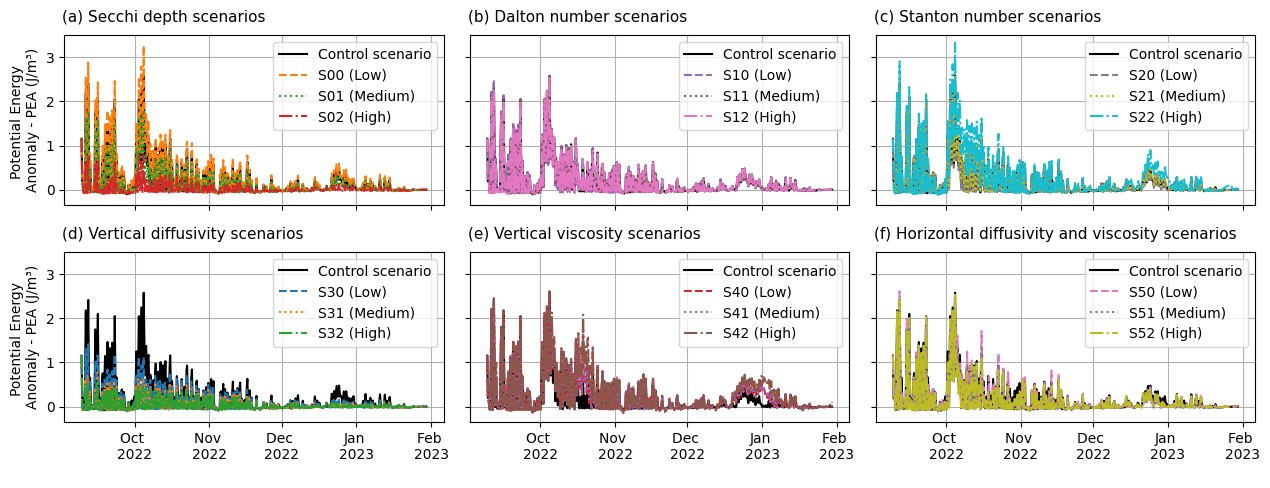

In [89]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [13,5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        ax[0,nplot].plot(PEA_ts_complete.index, PEA_ts_complete['PEA_con'], color='k', 
                           linestyle='-', label = 'Control scenario')        
        ax[0,nplot].plot(PEA_ts_complete.index, 
                         PEA_ts_complete[PEA_ts_complete.columns[1+3*nplot]], 
                         color=pal.as_hex()[1+3*nplot], 
                         linestyle='--', 
                         label = os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:7] + ' (Low)')
        ax[0,nplot].plot(PEA_ts_complete.index, 
                         PEA_ts_complete[PEA_ts_complete.columns[2+3*nplot]], 
                         color=pal.as_hex()[2+3*nplot], 
                         linestyle=':', 
                         label = os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:7] + ' (Medium)')
        ax[0,nplot].plot(PEA_ts_complete.index, 
                         PEA_ts_complete[PEA_ts_complete.columns[3+3*nplot]], 
                         color=pal.as_hex()[3+3*nplot], 
                         linestyle='-.', 
                         label = os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:7] + ' (High)')
        ax[0,nplot].set_xlim(ax[0,nplot].get_xlim()[0], ax[0,nplot].get_xlim()[-1])
#         ax[0,nplot].set_ylim(8.4,9)
        ax[0,nplot].legend(loc = 'upper right')
        ax[0,nplot].grid(True)

    # second row of plots
    if (3 <= nplot & nplot < 6):
        ax[1,nplot-3].plot(PEA_ts_complete.index, PEA_ts_complete['PEA_con'], color='k', 
                           linestyle='-', label = 'Control scenario')        
        ax[1,nplot-3].plot(PEA_ts_complete.index, 
                           PEA_ts_complete[PEA_ts_complete.columns[1+3*nplot]], 
                           color=pal.as_hex()[1+3*nplot], 
                           linestyle='--', 
                           label = os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:7] + ' (Low)')
        ax[1,nplot-3].plot(PEA_ts_complete.index, 
                           PEA_ts_complete[PEA_ts_complete.columns[2+3*nplot]], 
                           color=pal.as_hex()[2+3*nplot], 
                           linestyle=':', 
                           label = os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:7] + ' (Medium)')
        ax[1,nplot-3].plot(PEA_ts_complete.index, 
                           PEA_ts_complete[PEA_ts_complete.columns[3+3*nplot]], 
                           color=pal.as_hex()[3+3*nplot], 
                           linestyle='-.', 
                           label = os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:7] + ' (High)')
        ax[1,nplot-3].legend(loc = 'upper right')
        ax[1,nplot-3].grid(True)

# Add formatted date labels
xlabels = ['Oct 2022', 'Nov 2022', 'Dec 2022', 'Jan 2023', 'Feb 2023']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[1,0].set_xticklabels(xlabels_new)

ax[0,0].yaxis.set_label_text(u'Potential Energy \nAnomaly - PEA (J/m³)')
ax[1,0].yaxis.set_label_text(u'Potential Energy \nAnomaly - PEA (J/m³)')

ax[0,0].text(19236, 3.8, '(a) Secchi depth scenarios', color = 'k', fontsize = 11)
ax[0,1].text(19236, 3.8, '(b) Dalton number scenarios', color = 'k', fontsize = 11)
ax[0,2].text(19236, 3.8, '(c) Stanton number scenarios', color = 'k', fontsize = 11)

ax[1,0].text(19236, 3.8, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 11)
ax[1,1].text(19236, 3.8, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 11)
ax[1,2].text(19236, 3.8, '(f) Horizontal diffusivity and viscosity scenarios', color = 'k', fontsize = 11)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('timeseries_scenarios_PEA_montaut.jpeg', dpi=600, bbox_inches='tight')

plt.show();

<ipython-input-90-23a1c3991dd0>:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1,0].set_xticklabels(xlabels_new)


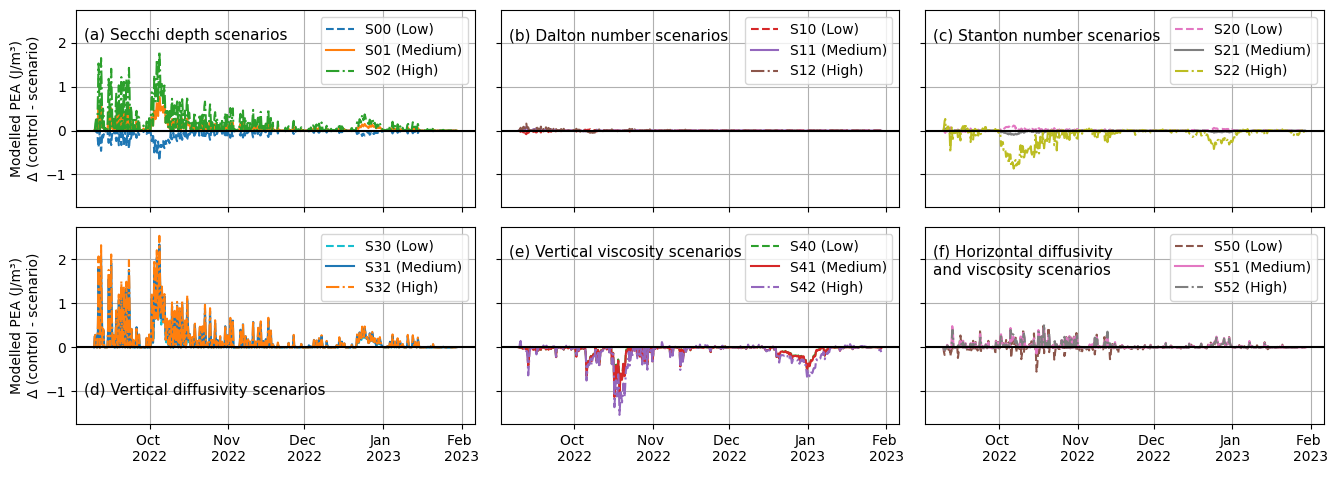

In [90]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [13.5,5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        ax[0,nplot].plot(delta_PEA.index, 
                         delta_PEA[delta_PEA.columns[0+3*nplot]], 
                         color=pal.as_hex()[0+3*nplot], 
                         linestyle='--', 
                         label = os.path.basename(delta_PEA.columns[0+3*nplot])[6:9] + ' (Low)')
        ax[0,nplot].plot(delta_PEA.index, 
                         delta_PEA[delta_PEA.columns[1+3*nplot]], 
                         color=pal.as_hex()[1+3*nplot], 
                         linestyle='-', 
                         label = os.path.basename(delta_PEA.columns[1+3*nplot])[6:9] + ' (Medium)')
        ax[0,nplot].plot(delta_PEA.index, 
                         delta_PEA[delta_PEA.columns[2+3*nplot]], 
                         color=pal.as_hex()[2+3*nplot], 
                         linestyle='-.', 
                         label = os.path.basename(delta_PEA.columns[2+3*nplot])[6:9] + ' (High)')
        ax[0,nplot].set_xlim(ax[0,nplot].get_xlim()[0], ax[0,nplot].get_xlim()[-1])
#         ax[0,nplot].set_ylim(-0.013,0.055)
        ax[0,nplot].hlines(y=0, xmin=ax[0,nplot].get_xlim()[0], xmax=ax[0,nplot].get_xlim()[-1],
                           color='k')
        ax[0,nplot].legend(loc = 'upper right')
        ax[0,nplot].grid(True)

    # second row of plots
    if (3 <= nplot & nplot < 6):
        ax[1,nplot-3].plot(delta_PEA.index, 
                           delta_PEA[delta_PEA.columns[0+3*nplot]], 
                           color=pal.as_hex()[0+3*nplot], 
                           linestyle='--', 
                           label = os.path.basename(delta_PEA.columns[0+3*nplot])[6:9] + ' (Low)')
        ax[1,nplot-3].plot(delta_PEA.index, 
                           delta_PEA[delta_PEA.columns[1+3*nplot]], 
                           color=pal.as_hex()[1+3*nplot], 
                           linestyle='-', 
                           label = os.path.basename(delta_PEA.columns[1+3*nplot])[6:9] + ' (Medium)')
        ax[1,nplot-3].plot(delta_PEA.index, 
                           delta_PEA[delta_PEA.columns[2+3*nplot]], 
                           color=pal.as_hex()[2+3*nplot], 
                           linestyle='-.', 
                           label = os.path.basename(delta_PEA.columns[2+3*nplot])[6:9] + ' (High)')
        ax[1,nplot-3].hlines(y=0, xmin=ax[1,nplot-3].get_xlim()[0], xmax=ax[1,nplot-3].get_xlim()[-1],
                             color='k')
        ax[1,nplot-3].legend(loc = 'upper right')
        ax[1,nplot-3].grid(True)
#         ax[1,nplot-3].set_xticks([0,1,2,3,4,5], 
#                                  ['Sep\n2022', 'Oct\n2022', 'Nov\n2022', 'Dec\n2022', 'Jan\n2023', 'Feb\n2023'])

# Add formatted date labels
xlabels = ['Oct 2022', 'Nov 2022', 'Dec 2022', 'Jan 2023', 'Feb 2023']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[1,0].set_xticklabels(xlabels_new)

ax[0,0].yaxis.set_label_text(u'Modelled PEA (J/m³)\nΔ (control - scenario)')
ax[1,0].yaxis.set_label_text(u'Modelled PEA (J/m³)\nΔ (control - scenario)')

ax[0,0].text(19240, 2.055, '(a) Secchi depth scenarios', color = 'k', fontsize = 11)
ax[0,1].text(19240, 2.055, '(b) Dalton number scenarios', color = 'k', fontsize = 11)
ax[0,2].text(19240, 2.055, '(c) Stanton number scenarios', color = 'k', fontsize = 11)

ax[1,0].text(19240, -1.08, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 11)
ax[1,1].text(19240, 2.055, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 11)
ax[1,2].text(19240, 1.65, '(f) Horizontal diffusivity\nand viscosity scenarios', color = 'k', fontsize = 11)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('delta_scenarios_PEA_montaut.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

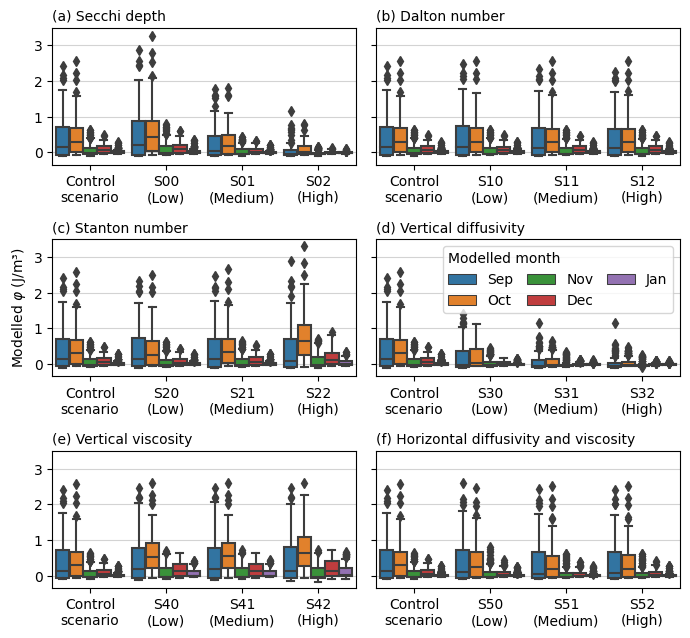

In [31]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = [7,6.5], sharey = True)
pal = sns.color_palette("tab10", 20)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 2):
        sns.boxplot(x = "scenario", y = "PEA", 
                    data = bp_comp_PEA.loc[bp_comp_PEA['scenario'].isin(['con',
                                                                         PEA_ts_complete.columns[1+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[2+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[3+3*nplot][4:9]])],
                        width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:5], ax = ax[0,nplot], hue = 'month_str')
        ax[0,nplot].set_xticks([0,1,2,3], ['Control\nscenario',
                                           os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:9] + '\n(Low)',
                                           os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:9] + '\n(Medium)',
                                           os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:9] + '\n(High)'],
                              fontsize = 10)
        ax[0,nplot].xaxis.set_label_text("")
        ax[0,nplot].yaxis.set_label_text('')
#         ax[0,nplot].set_ylim(8.5,8.9)
        ax[0,nplot].set_axisbelow(True)
        ax[0,nplot].grid(color='lightgray', axis = 'y')
        ax[0,nplot].legend_.remove()
        ax[0,nplot].tick_params(axis = 'y', which = 'major', labelsize = 10)
    
    # second row of plots
    if (2 <= nplot & nplot < 4):
        sns.boxplot(x = "scenario", y = "PEA", 
                    data = bp_comp_PEA.loc[bp_comp_PEA['scenario'].isin(['con',
                                                                         PEA_ts_complete.columns[1+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[2+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[3+3*nplot][4:9]])],
                    width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:5], ax = ax[1,nplot-2], hue = 'month_str')
        ax[1,nplot-2].set_xticks([0,1,2,3], ['Control\nscenario',
                                             os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:9] + '\n(Low)',
                                             os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:9] + '\n(Medium)',
                                             os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:9] + '\n(High)'], 
                                fontsize = 10)
        ax[1,nplot-2].xaxis.set_label_text("")
        ax[1,nplot-2].yaxis.set_label_text('')
        ax[1,nplot-2].set_axisbelow(True)
        ax[1,nplot-2].grid(color='lightgray', axis = 'y')
        ax[1,nplot-2].legend_.remove()
        ax[1,nplot-2].tick_params(axis = 'y', which = 'major', labelsize = 10)

    # second row of plots
    if (4 <= nplot & nplot < 6):
        sns.boxplot(x = "scenario", y = "PEA", 
                    data = bp_comp_PEA.loc[bp_comp_PEA['scenario'].isin(['con',
                                                                         PEA_ts_complete.columns[1+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[2+3*nplot][4:9],
                                                                         PEA_ts_complete.columns[3+3*nplot][4:9]])],
                    width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:5], ax = ax[2,nplot-4], hue = 'month_str')
        ax[2,nplot-4].set_xticks([0,1,2,3], ['Control\nscenario',
                                             os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:9] + '\n(Low)',
                                             os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:9] + '\n(Medium)',
                                             os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:9] + '\n(High)'], 
                                fontsize = 10)
        ax[2,nplot-4].xaxis.set_label_text("")
        ax[2,nplot-4].yaxis.set_label_text('')
        ax[2,nplot-4].set_axisbelow(True)
        ax[2,nplot-4].grid(color='lightgray', axis = 'y')
        ax[2,nplot-4].legend_.remove()
        ax[2,nplot-4].tick_params(axis = 'y', which = 'major', labelsize = 10)

# ax[0,0].vlines(x = 0.5, ymin = 8.5, ymax = 8.9,  color='k', linestyle='--')
# ax[1,0].vlines(x = 0.5, ymin = 8.5, ymax = 8.9,  color='k', linestyle='--')

ax[1,0].yaxis.set_label_text(('Modelled ' + r'$\varphi$' + ' (J/m³)'), fontsize = 10)

ax[0,0].text(-0.5, 3.7, '(a) Secchi depth', color = 'k', fontsize = 10)
ax[0,1].text(-0.5, 3.7, '(b) Dalton number', color = 'k', fontsize = 10)

ax[1,0].text(-0.5, 3.7, '(c) Stanton number', color = 'k', fontsize = 10)
ax[1,1].text(-0.5, 3.7, '(d) Vertical diffusivity', color = 'k', fontsize = 10)

ax[2,0].text(-0.5, 3.7, '(e) Vertical viscosity', color = 'k', fontsize = 10)
ax[2,1].text(-0.5, 3.7, '(f) Horizontal diffusivity and viscosity', color = 'k', fontsize = 10)

# ax[0,0].legend(bbox_to_anchor=(0.96,0.295), loc="lower right",  bbox_transform=fig.transFigure)

ax[1,1].legend(title = "Modelled month", loc="upper right", ncol = 3, fontsize = 10, 
               frameon = True, columnspacing = 1)._legend_box.align = "left"

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('monthly_boxplots_scenarios_PEA_montaut.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

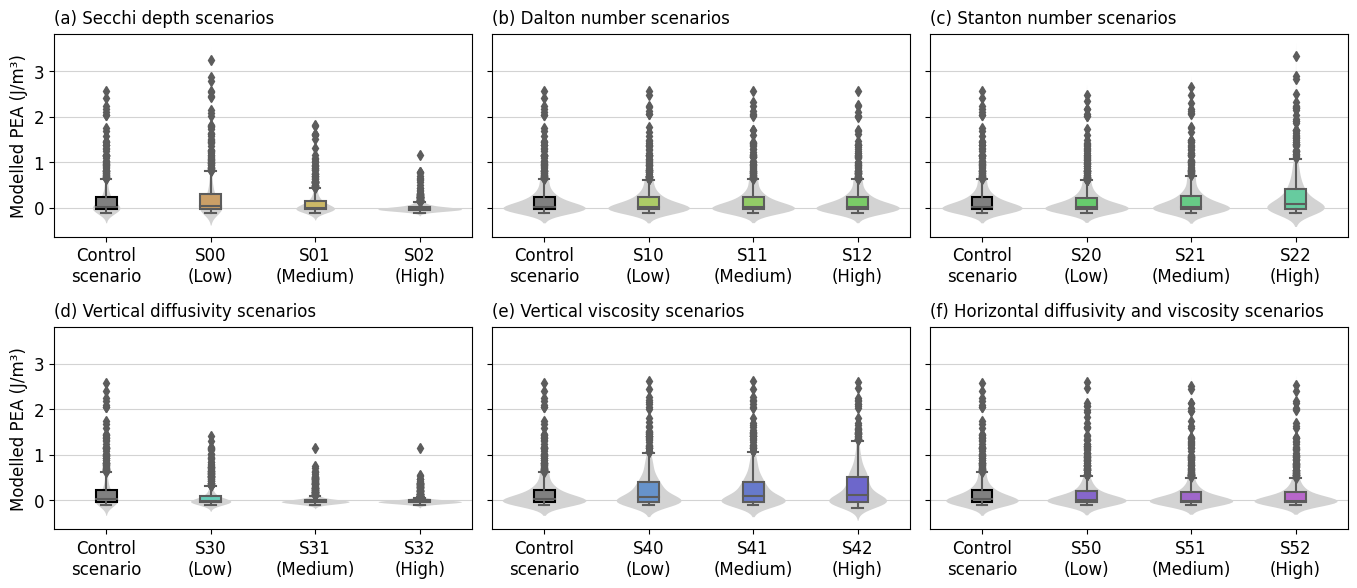

In [75]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = [14,6], sharey = True)
pal = sns.color_palette("hls", 24)

plot_number = (len(all_files_hist))/3

for nplot in range(0,int(plot_number),1):
    # first row of plots
    if (0 <= nplot & nplot < 3):
        sns.boxplot(x = "variable", y = "value", 
                    data = pd.melt(PEA_ts_complete[['PEA_con',
                                                    PEA_ts_complete.columns[1+3*nplot],
                                                    PEA_ts_complete.columns[2+3*nplot], 
                                                    PEA_ts_complete.columns[3+3*nplot]]]),
                    width = 0.2, boxprops = {'zorder': 2}, palette = pal[(1+3*nplot):(3+3*nplot)+2], ax = ax[0,nplot])
        sns.violinplot(data = PEA_ts_complete[['PEA_con', 
                                               PEA_ts_complete.columns[1+3*nplot],
                                               PEA_ts_complete.columns[2+3*nplot], 
                                               PEA_ts_complete.columns[3+3*nplot]]],
                       inner = None, linewidth = 0, width = 0.8, color = 'lightgray', ax = ax[0,nplot])
        ax[0,nplot].set_xticks([0,1,2,3], ['Control\nscenario',
                                           os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:9] + '\n(Low)',
                                           os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:9] + '\n(Medium)',
                                           os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:9] + '\n(High)'],
                              fontsize = 12)
        control_plot = ax[0,nplot].patches[0]
        control_plot.set_facecolor('gray')
        control_plot.set_edgecolor('black')
        ax[0,nplot].xaxis.set_label_text("")
        ax[0,nplot].yaxis.set_label_text('')
        ax[0,nplot].set_axisbelow(True)
        ax[0,nplot].grid(color='lightgray', axis = 'y')
        ax[0,nplot].tick_params(axis = 'y', which = 'major', labelsize = 12)

    # second row of plots
    if (3 <= nplot & nplot < 6):
        sns.boxplot(x = "variable", y = "value", 
                    data = pd.melt(PEA_ts_complete[['PEA_con', 
                                                    PEA_ts_complete.columns[1+3*nplot],
                                                    PEA_ts_complete.columns[2+3*nplot], 
                                                    PEA_ts_complete.columns[3+3*nplot]]]),
                    width = 0.2, boxprops = {'zorder': 2}, palette = pal[(1+3*nplot):(3+3*nplot)+2], ax = ax[1,nplot-3])
        sns.violinplot(data = PEA_ts_complete[['PEA_con', 
                                               PEA_ts_complete.columns[1+3*nplot],
                                               PEA_ts_complete.columns[2+3*nplot], 
                                               PEA_ts_complete.columns[3+3*nplot]]],
                       inner = None, linewidth = 0, width = 0.8, color = 'lightgray', ax = ax[1,nplot-3])
        ax[1,nplot-3].set_xticks([0,1,2,3], ['Control\nscenario',
                                             os.path.basename(PEA_ts_complete.columns[1+3*nplot])[4:9] + '\n(Low)',
                                             os.path.basename(PEA_ts_complete.columns[2+3*nplot])[4:9] + '\n(Medium)',
                                             os.path.basename(PEA_ts_complete.columns[3+3*nplot])[4:9] + '\n(High)'],
                                fontsize = 12)
        control_plot = ax[1,nplot-3].patches[0]
        control_plot.set_facecolor('gray')
        control_plot.set_edgecolor('black')
        ax[1,nplot-3].xaxis.set_label_text("")
        ax[1,nplot-3].yaxis.set_label_text('')
        ax[1,nplot-3].set_axisbelow(True)
        ax[1,nplot-3].grid(color='lightgray', axis = 'y')
        ax[1,nplot-3].tick_params(axis = 'y', which = 'major', labelsize = 12)
        
ax[0,0].yaxis.set_label_text(u'Modelled PEA (J/m³)', fontsize = 12)
ax[1,0].yaxis.set_label_text(u'Modelled PEA (J/m³)', fontsize = 12)

ax[0,0].text(-0.5, 4.05, '(a) Secchi depth scenarios', color = 'k', fontsize = 12)
ax[0,1].text(-0.5, 4.05, '(b) Dalton number scenarios', color = 'k', fontsize = 12)
ax[0,2].text(-0.5, 4.05, '(c) Stanton number scenarios', color = 'k', fontsize = 12)

ax[1,0].text(-0.5, 4.05, '(d) Vertical diffusivity scenarios', color = 'k', fontsize = 12)
ax[1,1].text(-0.5, 4.05, '(e) Vertical viscosity scenarios', color = 'k', fontsize = 12)
ax[1,2].text(-0.5, 4.05, '(f) Horizontal diffusivity and viscosity scenarios', color = 'k', fontsize = 12)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('boxplots_scenarios_PEA_controlunique_montaut.jpeg', dpi=600, bbox_inches='tight')

plt.show();